In [2]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)

# Carga de datos
tw = pd.read_parquet('../data/processed/tweets_op_sectored.parquet')
yt = pd.read_parquet('../data/processed/youtube_sentiment_v2.parquet')

# Asegurar tipos datetime
tw['created_at'] = pd.to_datetime(tw['created_at'], utc=True, errors='coerce')
tw['year']       = tw['created_at'].dt.year

yt['date'] = pd.to_datetime(yt['date'], utc=True, errors='coerce')
yt['year'] = yt['date'].dt.year


In [3]:
sep = '═' * 60

print(sep)
print('  TWITTER — tweets_op_sectored.parquet')
print(sep)
print(f'  Total registros         : {len(tw):>10,}')
print(f'  Rango temporal          : {tw["year"].min()} – {tw["year"].max()}')
print(f'  Columna de texto        : tweet_clean_filt')
print(f'  Columna de sentimiento  : sentiment_label_hf')
print(f'  Columna de sector       : sector')
print()
print('  Distribución por año:')
tw_anual     = tw.groupby('year').size().rename('n_tweets')
tw_anual_pct = (tw_anual / tw_anual.sum() * 100).round(1).rename('pct %')
print(pd.concat([tw_anual, tw_anual_pct], axis=1).to_string())
print()
print('  Distribución de sentimiento global:')
print(tw['sentiment_label_hf'].value_counts(normalize=True)
        .mul(100).round(1).rename('pct %').to_string())
print()
print('  Distribución por sector:')
print(tw['sector'].value_counts().to_string())

════════════════════════════════════════════════════════════
  TWITTER — tweets_op_sectored.parquet
════════════════════════════════════════════════════════════
  Total registros         :    123,389
  Rango temporal          : 2017 – 2021
  Columna de texto        : tweet_clean_filt
  Columna de sentimiento  : sentiment_label_hf
  Columna de sector       : sector

  Distribución por año:
      n_tweets  pct %
year                 
2017     29290   23.7
2018     33721   27.3
2019     37739   30.6
2020     15248   12.4
2021      7391    6.0

  Distribución de sentimiento global:
sentiment_label_hf
neutral     56.7
positive    27.8
negative    15.5

  Distribución por sector:
sector
other         101258
employment     15499
education       6632


In [4]:
print(sep)
print('  YOUTUBE — youtube_sentiment_v2.parquet')
print(sep)
print(f'  Total registros         : {len(yt):>10,}')
print(f'  Rango temporal          : {yt["year"].min()} – {yt["year"].max()}')
print(f'  Vídeos únicos           : {yt["video_id"].nunique():>10,}')
print(f'  Canales únicos          : {yt["channel"].nunique():>10,}')
print(f'  Columna de texto        : text_clean')
print(f'  Columna de sentimiento  : sentiment_label')
print(f'  Columna de sector       : topic')
print()
print('  Distribución por año:')
yt_anual     = yt.groupby('year').size().rename('n_comentarios')
yt_anual_pct = (yt_anual / yt_anual.sum() * 100).round(1).rename('pct %')
print(pd.concat([yt_anual, yt_anual_pct], axis=1).to_string())
print()
print('  Distribución de sentimiento global:')
print(yt['sentiment_label'].value_counts(normalize=True)
        .mul(100).round(1).rename('pct %').to_string())
print()
print('  Distribución por topic:')
print(yt['topic'].value_counts().to_string())

════════════════════════════════════════════════════════════
  YOUTUBE — youtube_sentiment_v2.parquet
════════════════════════════════════════════════════════════
  Total registros         :     62,989
  Rango temporal          : 2020 – 2026
  Vídeos únicos           :        372
  Canales únicos          :        248
  Columna de texto        : text_clean
  Columna de sentimiento  : sentiment_label
  Columna de sector       : topic

  Distribución por año:
      n_comentarios  pct %
year                      
2020           1278    2.0
2021           1763    2.8
2022           4081    6.5
2023          10497   16.7
2024          13655   21.7
2025          17425   27.7
2026          14290   22.7

  Distribución de sentimiento global:
sentiment_label
negative    52.9
neutral     26.0
positive    21.1

  Distribución por topic:
topic
general       36895
education     10677
employment    10439
both           4978


In [5]:
tw_overlap = tw[tw['year'].isin([2020, 2021])]
yt_overlap = yt[yt['year'].isin([2020, 2021])]

print(sep)
print('  PERÍODO SOLAPADO 2020–2021')
print(sep)
print(f'  Twitter    : {len(tw_overlap):>8,} tweets      '
      f'({len(tw_overlap)/len(tw)*100:.1f}% del corpus Twitter)')
print(f'  YouTube    : {len(yt_overlap):>8,} comentarios '
      f'({len(yt_overlap)/len(yt)*100:.1f}% del corpus YouTube)')
print()
print('  Twitter 2020–2021 — sentimiento:')
print(tw_overlap['sentiment_label_hf'].value_counts(normalize=True)
        .mul(100).round(1).rename('pct %').to_string())
print()
print('  YouTube 2020–2021 — sentimiento:')
print(yt_overlap['sentiment_label'].value_counts(normalize=True)
        .mul(100).round(1).rename('pct %').to_string())
print()
print('  Twitter 2020–2021 — por año:')
print(tw_overlap.groupby('year').size().to_string())
print()
print('  YouTube 2020–2021 — por año:')
print(yt_overlap.groupby('year').size().to_string())
print()

# Resumen ejecutivo
tw_sec = tw[tw['sector'].isin(['education', 'employment'])]
yt_sec = yt[yt['topic'].isin(['education', 'employment', 'both'])]

print(sep)
print('  RESUMEN EJECUTIVO')
print(sep)
print(f'  Corpus Twitter total    : {len(tw):>8,} tweets      (2017–2021)')
print(f'  Corpus YouTube total    : {len(yt):>8,} comentarios (2020–2026)')
print(f'  Total registros         : {len(tw)+len(yt):>8,}')
print()
print('  Cobertura sectorial (education + employment):')
print(f'    Twitter con sector    : {len(tw_sec):>8,} ({len(tw_sec)/len(tw)*100:.1f}%)')
print(f'    YouTube con sector    : {len(yt_sec):>8,} ({len(yt_sec)/len(yt)*100:.1f}%)')
print()
print('  ADVERTENCIAS:')
print('  · 2026 en YouTube solo cubre enero–marzo.')
print('  · El volumen de YouTube refleja el diseño de recolección,')
print('    no la actividad real en la plataforma.')

════════════════════════════════════════════════════════════
  PERÍODO SOLAPADO 2020–2021
════════════════════════════════════════════════════════════
  Twitter    :   22,639 tweets      (18.3% del corpus Twitter)
  YouTube    :    3,041 comentarios (4.8% del corpus YouTube)

  Twitter 2020–2021 — sentimiento:
sentiment_label_hf
neutral     51.9
positive    28.4
negative    19.8

  YouTube 2020–2021 — sentimiento:
sentiment_label
negative    38.1
neutral     37.1
positive    24.8

  Twitter 2020–2021 — por año:
year
2020    15248
2021     7391

  YouTube 2020–2021 — por año:
year
2020    1278
2021    1763

════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO
════════════════════════════════════════════════════════════
  Corpus Twitter total    :  123,389 tweets      (2017–2021)
  Corpus YouTube total    :   62,989 comentarios (2020–2026)
  Total registros         :  186,378

  Cobertura sectorial (education + employment):
    Twitter con sector    :   22,131

## Grafica de comparacion de longitud de texto entre plataformas

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Calcular longitud en palabras ────────────────────────────────────────────
tw['n_palabras'] = tw['tweet_clean_filt'].dropna().apply(lambda x: len(str(x).split()))
yt['n_palabras'] = yt['text_clean'].dropna().apply(lambda x: len(str(x).split()))

# ── Estadísticas descriptivas ────────────────────────────────────────────────
print('LONGITUD DE TEXTO — estadísticas descriptivas (palabras)\n')
print(f"{'':25} {'Twitter':>10} {'YouTube':>10}")
print('─' * 47)
print(f"{'Media':25} {tw['n_palabras'].mean():>10.1f} {yt['n_palabras'].mean():>10.1f}")
print(f"{'Mediana':25} {tw['n_palabras'].median():>10.1f} {yt['n_palabras'].median():>10.1f}")
print(f"{'P75':25} {tw['n_palabras'].quantile(0.75):>10.1f} {yt['n_palabras'].quantile(0.75):>10.1f}")
print(f"{'P90':25} {tw['n_palabras'].quantile(0.90):>10.1f} {yt['n_palabras'].quantile(0.90):>10.1f}")
print(f"{'Máximo':25} {tw['n_palabras'].max():>10.0f} {yt['n_palabras'].max():>10.0f}")

LONGITUD DE TEXTO — estadísticas descriptivas (palabras)

                             Twitter    YouTube
───────────────────────────────────────────────
Media                           19.2       44.1
Mediana                         16.0       25.0
P75                             26.0       46.0
P90                             38.0       89.0
Máximo                            63       1888


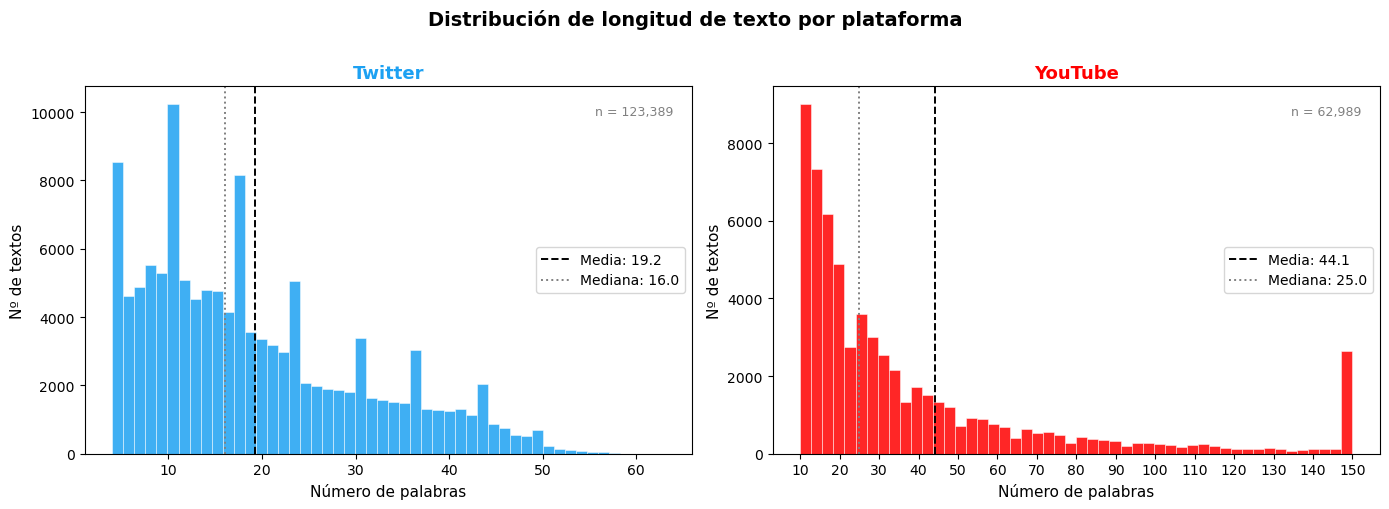

Guardado: figures/10_longitud_texto.png


In [9]:
# ── Gráfico ──────────────────────────────────────────────────────────────────
CLIP = 150  # Cortamos en 100 palabras para que el gráfico sea legible
            # Los extremos (tweets >100 palabras) son outliers irrelevantes visualmente

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Distribución de longitud de texto por plataforma', fontsize=14, fontweight='bold', y=1.01)

COLOR_TW = '#1DA1F2'  # azul Twitter
COLOR_YT = '#FF0000'  # rojo YouTube

# Percentiles para anotar en el gráfico
for ax, df_plot, color, label, col in [
    (axes[0], tw, COLOR_TW, 'Twitter', 'n_palabras'),
    (axes[1], yt, COLOR_YT, 'YouTube', 'n_palabras'),
]:
    data = df_plot[col].clip(upper=CLIP)
    
    ax.hist(data, bins=50, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    
    media   = df_plot[col].mean()
    mediana = df_plot[col].median()
    
    ax.axvline(media,   color='black',  linestyle='--', linewidth=1.4, label=f'Media: {media:.1f}')
    ax.axvline(mediana, color='grey',   linestyle=':',  linewidth=1.4, label=f'Mediana: {mediana:.1f}')
    
    ax.set_title(label, fontsize=13, fontweight='bold', color=color)
    ax.set_xlabel('Número de palabras', fontsize=11)
    ax.set_ylabel('Nº de textos', fontsize=11)
    ax.legend(fontsize=10)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
    ax.text(0.97, 0.95, f'n = {len(df_plot):,}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('../figures/10_longitud_texto.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: figures/10_longitud_texto.png')

## Evolucion temporal de sentimiento - crossplatform

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd

# ── Preparar series mensuales ────────────────────────────────────────────────
tw['month'] = tw['created_at'].dt.to_period('M')
yt['month'] = yt['date'].dt.to_period('M')

def monthly_sentiment(df, sentiment_col):
    counts = (
        df.groupby(['month', sentiment_col])
        .size()
        .unstack(fill_value=0)
    )
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    pct.index = pct.index.to_timestamp()
    return pct

tw_monthly = monthly_sentiment(tw, 'sentiment_label_hf')
yt_monthly = monthly_sentiment(yt, 'sentiment_label')

# ── Colores fijos ────────────────────────────────────────────────────────────
C_NEG = '#e74c3c'
C_POS = '#2ecc71'
C_NEU = '#95a5a6'
C_TW  = '#1DA1F2'
C_YT  = '#FF0000'

# ── Hitos ────────────────────────────────────────────────────────────────────
HITOS = {
    '2020-06': 'GPT-3',
    '2021-01': 'DALL-E',
    '2022-11': 'ChatGPT',
    '2023-03': 'GPT-4',
    '2023-12': 'Gemini',
    '2024-06': 'EU AI Act',
}

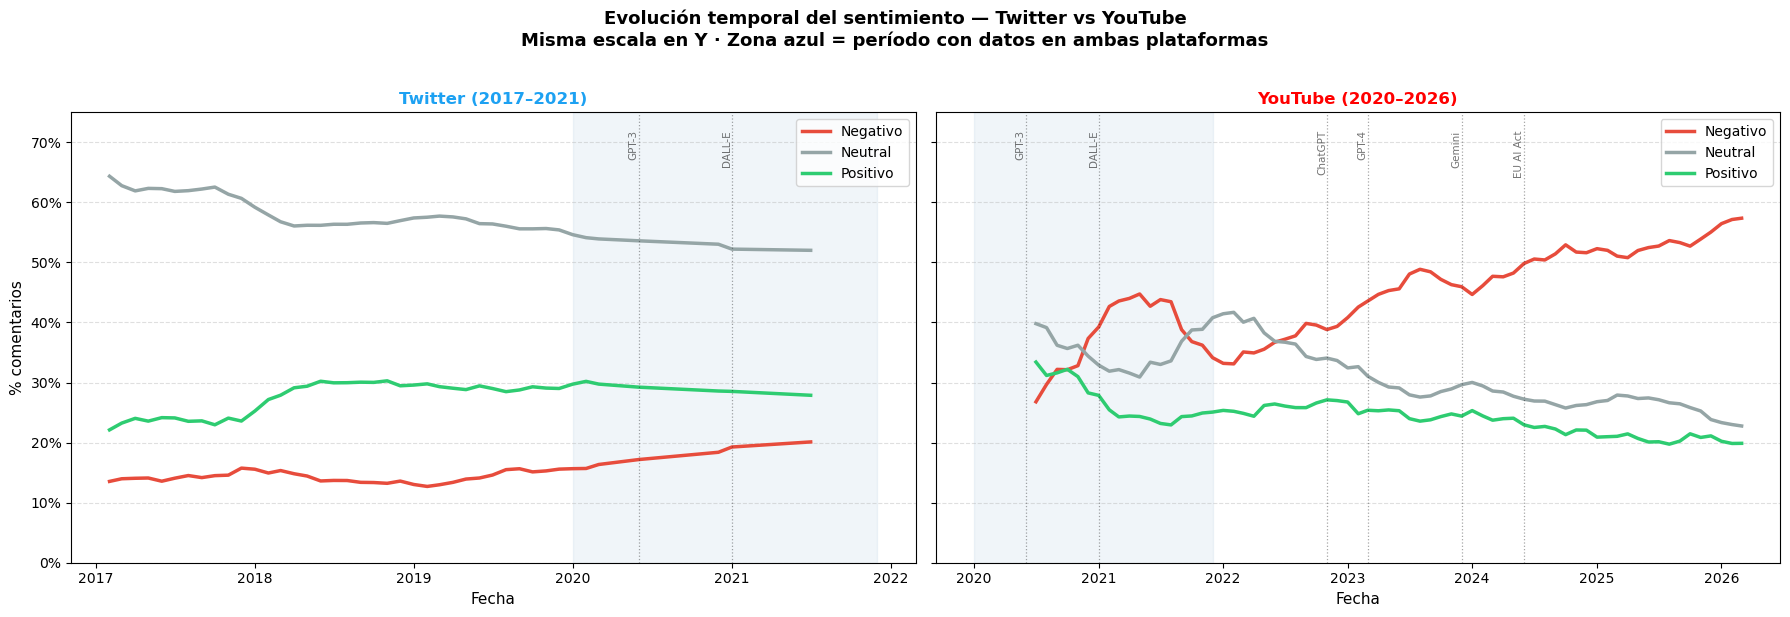

Guardado: figures/10_evolucion_temporal_v5.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

SENTIMENTS = [
    ('negative', 'Negativo', '#e74c3c'),
    ('neutral',  'Neutral',  '#95a5a6'),
    ('positive', 'Positivo', '#2ecc71'),
]

WINDOW_TW = 6
WINDOW_YT = 9

# ── TWITTER ──────────────────────────────────────────────────────────────────
ax_tw = axes[0]
for sent, label, color in SENTIMENTS:
    if sent in tw_monthly.columns:
        tw_s = tw_monthly[sent].rolling(WINDOW_TW, min_periods=2).mean()
        ax_tw.plot(tw_monthly.index, tw_s,
                   color=color, linewidth=2.5, linestyle='-', label=label)

ax_tw.axvspan(pd.Timestamp('2020-01'), pd.Timestamp('2021-12'),
              alpha=0.08, color='steelblue')

for fecha, nombre in HITOS.items():
    ts = pd.Timestamp(fecha)
    if ts <= pd.Timestamp('2021-12'):
        ax_tw.axvline(ts, color='black', linestyle=':', linewidth=0.9, alpha=0.35)
        ax_tw.text(ts, 72, nombre, rotation=90, fontsize=7.5,
                   va='top', ha='right', alpha=0.55)

ax_tw.set_title('Twitter (2017–2021)',
                fontsize=12, fontweight='bold', color='#1DA1F2')
ax_tw.set_ylabel('% comentarios', fontsize=11)
ax_tw.set_xlabel('Fecha', fontsize=11)
ax_tw.set_ylim(0, 75)
ax_tw.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax_tw.legend(fontsize=10, loc='upper right')
ax_tw.grid(axis='y', linestyle='--', alpha=0.4)

# ── YOUTUBE ──────────────────────────────────────────────────────────────────
ax_yt = axes[1]
for sent, label, color in SENTIMENTS:
    if sent in yt_monthly.columns:
        yt_s = yt_monthly[sent].rolling(WINDOW_YT, min_periods=3).mean()
        ax_yt.plot(yt_monthly.index, yt_s,
                   color=color, linewidth=2.5, linestyle='-', label=label)

ax_yt.axvspan(pd.Timestamp('2020-01'), pd.Timestamp('2021-12'),
              alpha=0.08, color='steelblue')

for fecha, nombre in HITOS.items():
    ts = pd.Timestamp(fecha)
    ax_yt.axvline(ts, color='black', linestyle=':', linewidth=0.9, alpha=0.35)
    ax_yt.text(ts, 72, nombre, rotation=90, fontsize=7.5,
               va='top', ha='right', alpha=0.55)

ax_yt.set_title('YouTube (2020–2026)',
                fontsize=12, fontweight='bold', color='#FF0000')
ax_yt.set_xlabel('Fecha', fontsize=11)
ax_yt.set_ylim(0, 75)
ax_yt.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax_yt.legend(fontsize=10, loc='upper right')
ax_yt.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Evolución temporal del sentimiento — Twitter vs YouTube\n'
             'Misma escala en Y · Zona azul = período con datos en ambas plataformas',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../figures/10_evolucion_temporal_v5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: figures/10_evolucion_temporal_v5.png')

## Comparativa de sentimiento global

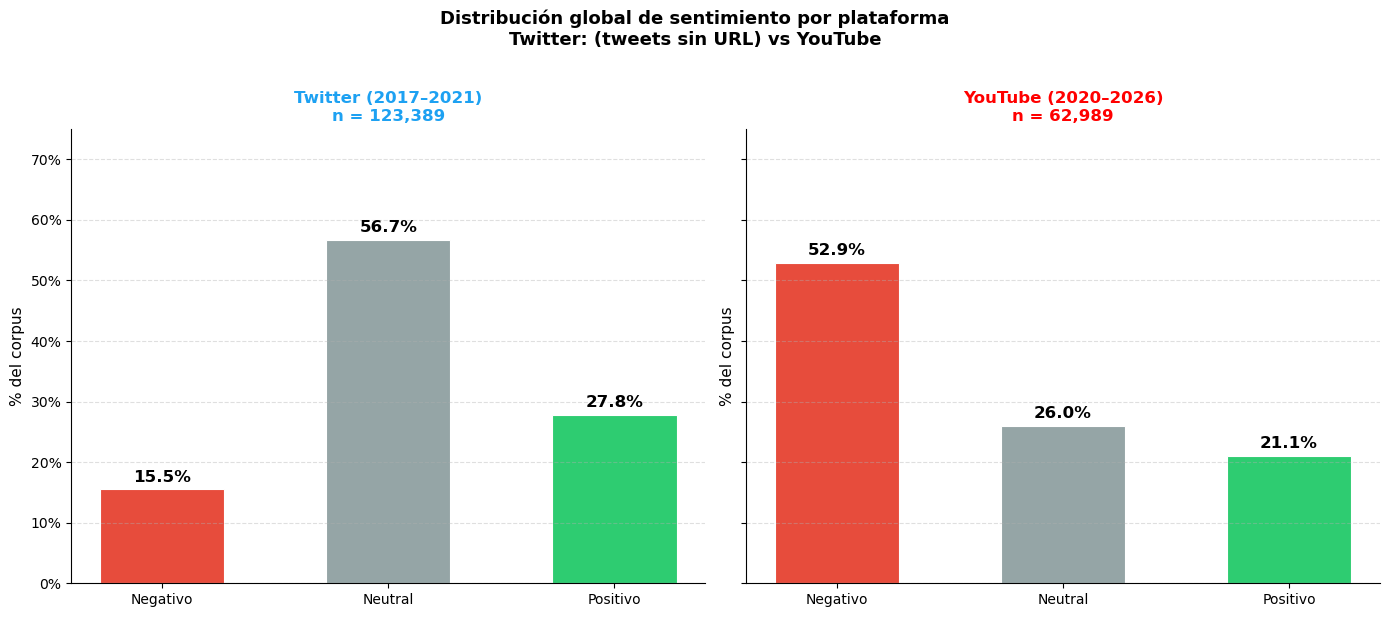

Guardado: figures/10_sentimiento_global.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

SENTIMENTS = ['negative', 'neutral', 'positive']
LABELS     = ['Negativo', 'Neutral', 'Positivo']
COLORS     = ['#e74c3c', '#95a5a6', '#2ecc71']

# ── Calcular distribuciones globales ─────────────────────────────────────────
tw_dist = tw['sentiment_label_hf'].value_counts(normalize=True).mul(100)
yt_dist = yt['sentiment_label'].value_counts(normalize=True).mul(100)

# Reordenar para que salgan en el mismo orden
tw_vals = [tw_dist.get(s, 0) for s in SENTIMENTS]
yt_vals = [yt_dist.get(s, 0) for s in SENTIMENTS]

for ax, vals, titulo, color_title, n in [
    (axes[0], tw_vals, 'Twitter (2017–2021)', '#1DA1F2', len(tw)),
    (axes[1], yt_vals, 'YouTube (2020–2026)', '#FF0000', len(yt)),
]:
    bars = ax.bar(LABELS, vals, color=COLORS, edgecolor='white',
                  linewidth=0.8, width=0.55)

    # Etiquetas encima de cada barra
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f'{val:.1f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_title(f'{titulo}\nn = {n:,}', fontsize=12,
                 fontweight='bold', color=color_title)
    ax.set_ylabel('% del corpus', fontsize=11)
    ax.set_ylim(0, 75)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribución global de sentimiento por plataforma\n'
             'Twitter: (tweets sin URL) vs YouTube',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../figures/10_sentimiento_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: figures/10_sentimiento_global.png')

## Sentimiento sectorial

Comparar cómo cada plataforma percibe cada sector

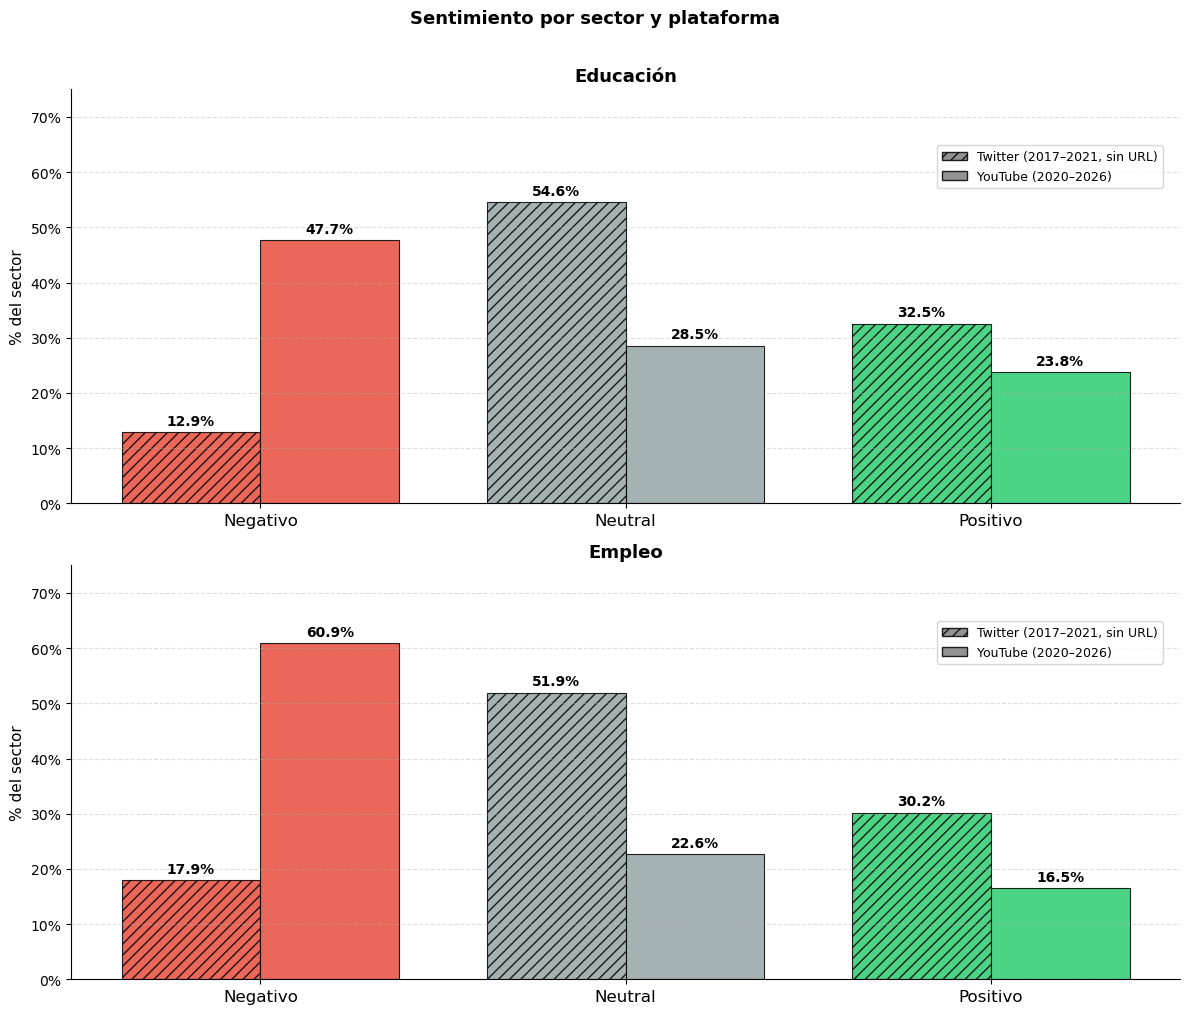

Guardado: figures/10_sentimiento_sectorial_v2.png


In [29]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

SENTIMENTS  = ['negative', 'neutral', 'positive']
LABELS_SENT = ['Negativo', 'Neutral', 'Positivo']
COLORS      = ['#e74c3c', '#95a5a6', '#2ecc71']

sectores = {
    'Educación': {
        'tw': tw[tw['sector'] == 'education'],
        'yt': yt[yt['sector_education'] == True],
    },
    'Empleo': {
        'tw': tw[tw['sector'] == 'employment'],
        'yt': yt[yt['sector_employment'] == True],
    },
}

for ax, (sector_label, datos) in zip(axes, sectores.items()):

    tw_sec = datos['tw']
    yt_sec = datos['yt']

    tw_dist = tw_sec['sentiment_label_hf'].value_counts(normalize=True).mul(100)
    yt_dist = yt_sec['sentiment_label'].value_counts(normalize=True).mul(100)

    tw_vals = [tw_dist.get(s, 0) for s in SENTIMENTS]
    yt_vals = [yt_dist.get(s, 0) for s in SENTIMENTS]

    x     = np.arange(len(SENTIMENTS))
    width = 0.38

    # Twitter — barras con borde y patrón rayado para distinguir sin depender del color
    bars_tw = ax.bar(x - width/2, tw_vals, width,
                     color=COLORS, edgecolor='black', linewidth=0.8,
                     hatch='///', alpha=0.85, label='Twitter (2017–2021, sin URL)')

    # YouTube — barras sólidas
    bars_yt = ax.bar(x + width/2, yt_vals, width,
                     color=COLORS, edgecolor='black', linewidth=0.8,
                     alpha=0.85, label='YouTube (2020–2026)')

    # Etiquetas de valor
    for bar, val in zip(bars_tw, tw_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    for bar, val in zip(bars_yt, yt_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    ax.set_title(sector_label, fontsize=13, fontweight='bold', loc='center')
    ax.set_xticks(x)
    ax.set_xticklabels(LABELS_SENT, fontsize=12)
    ax.set_ylabel('% del sector', fontsize=11)
    ax.set_ylim(0, 75)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)


    # Leyenda con hatch para diferenciar plataformas
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='grey', edgecolor='black', hatch='///', alpha=0.85,
              label='Twitter (2017–2021, sin URL)'),
        Patch(facecolor='grey', edgecolor='black', alpha=0.85,
              label='YouTube (2020–2026)'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='upper right',
              bbox_to_anchor=(0.99, 0.88))

fig.suptitle('Sentimiento por sector y plataforma',
             fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('../figures/10_sentimiento_sectorial_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: figures/10_sentimiento_sectorial_v2.png')

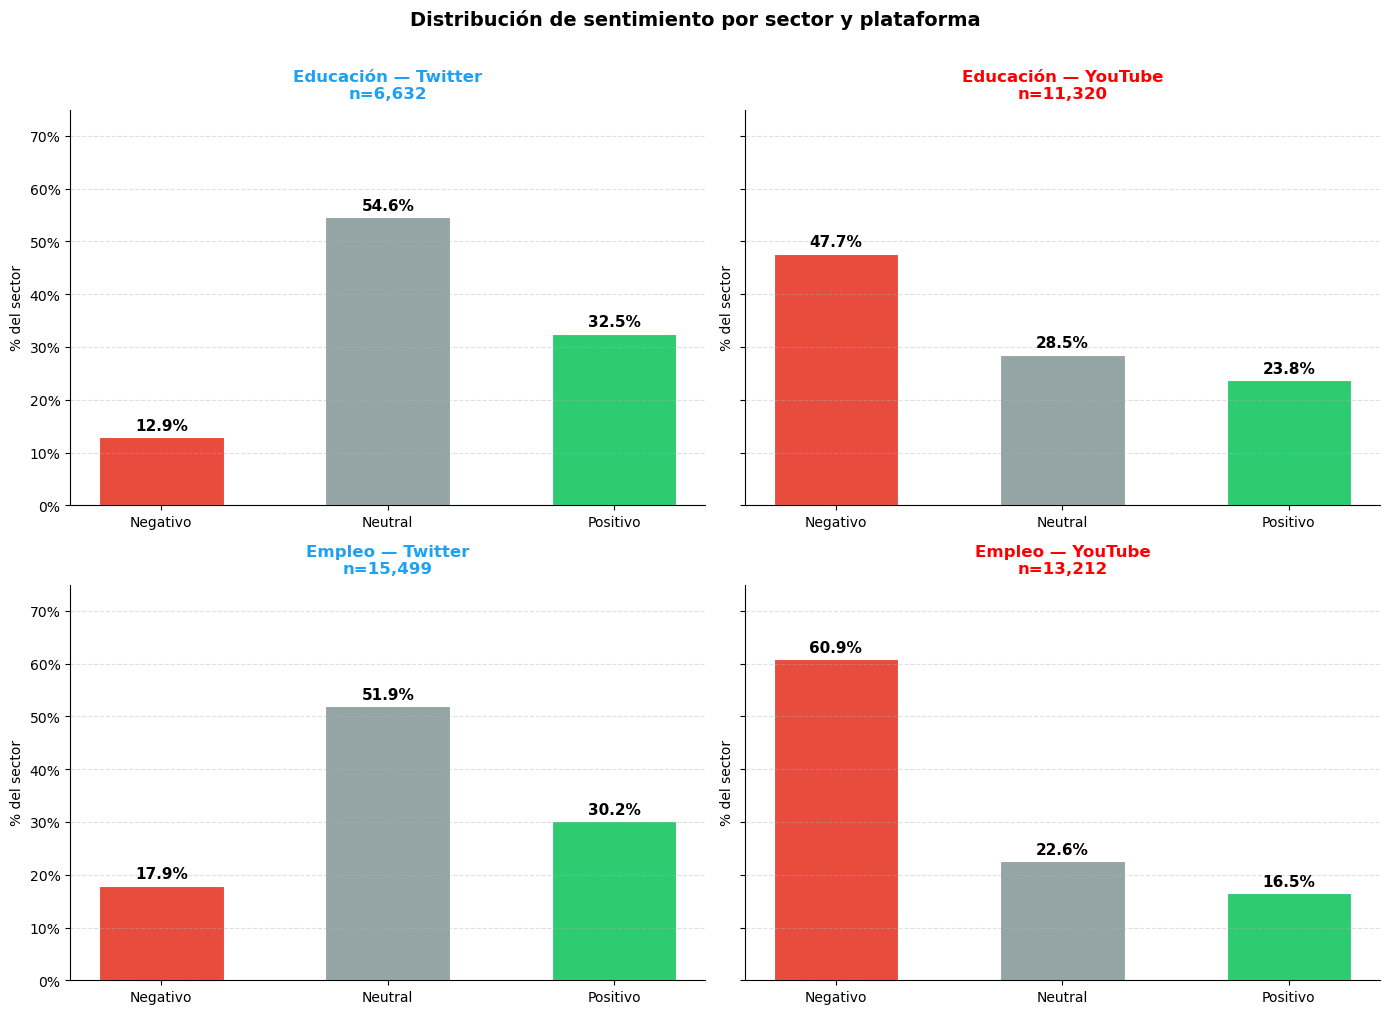

Guardado: figures/10_sentimiento_sectorial_v3.png


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

SENTIMENTS  = ['negative', 'neutral', 'positive']
LABELS_SENT = ['Negativo', 'Neutral', 'Positivo']
COLORS      = ['#e74c3c', '#95a5a6', '#2ecc71']

subplots = [
    (axes[0, 0], 'Educación — Twitter',    tw[tw['sector'] == 'education'],    '#1DA1F2', 'sentiment_label_hf'),
    (axes[0, 1], 'Educación — YouTube',    yt[yt['sector_education'] == True], '#FF0000', 'sentiment_label'),
    (axes[1, 0], 'Empleo — Twitter',       tw[tw['sector'] == 'employment'],   '#1DA1F2', 'sentiment_label_hf'),
    (axes[1, 1], 'Empleo — YouTube',       yt[yt['sector_employment'] == True],'#FF0000', 'sentiment_label'),
]

for ax, titulo, datos, color_titulo, sent_col in subplots:

    dist = datos[sent_col].value_counts(normalize=True).mul(100)
    vals = [dist.get(s, 0) for s in SENTIMENTS]

    bars = ax.bar(LABELS_SENT, vals, color=COLORS,
                  edgecolor='white', linewidth=0.8, width=0.55)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold')

    ax.set_title(f'{titulo}\nn={len(datos):,}', fontsize=12,
                 fontweight='bold', color=color_titulo, pad=8)
    ax.set_ylim(0, 75)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_ylabel('% del sector', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribución de sentimiento por sector y plataforma',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('../figures/10_sentimiento_sectorial_v3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: figures/10_sentimiento_sectorial_v3.png')

## Tabla resumen

In [30]:
import pandas as pd

# ── Datos para la tabla ──────────────────────────────────────────────────────
tw_edu = tw[tw['sector'] == 'education']
tw_emp = tw[tw['sector'] == 'employment']
yt_edu = yt[yt['sector_education'] == True]
yt_emp = yt[yt['sector_employment'] == True]

tw_global = tw['sentiment_label_hf'].value_counts(normalize=True).mul(100)
yt_global = yt['sentiment_label'].value_counts(normalize=True).mul(100)

tw_ov = tw[tw['year'].isin([2020, 2021])]['sentiment_label_hf'].value_counts(normalize=True).mul(100)
yt_ov = yt[yt['year'].isin([2020, 2021])]['sentiment_label'].value_counts(normalize=True).mul(100)

tw_edu_dist = tw_edu['sentiment_label_hf'].value_counts(normalize=True).mul(100)
yt_edu_dist = yt_edu['sentiment_label'].value_counts(normalize=True).mul(100)
tw_emp_dist = tw_emp['sentiment_label_hf'].value_counts(normalize=True).mul(100)
yt_emp_dist = yt_emp['sentiment_label'].value_counts(normalize=True).mul(100)

# ── Construcción de la tabla ─────────────────────────────────────────────────
tabla = pd.DataFrame({
    'Métrica': [
        'Período',
        'N total',
        'Longitud mediana (palabras)',
        '% Negativo global',
        '% Neutral global',
        '% Positivo global',
        '% Negativo — Educación',
        '% Neutral  — Educación',
        '% Positivo — Educación',
        '% Negativo — Empleo',
        '% Neutral  — Empleo',
        '% Positivo — Empleo',
        '% Negativo — Solapado 2020–2021',
        '% Neutral  — Solapado 2020–2021',
        '% Positivo — Solapado 2020–2021',
        'N solapado 2020–2021',
    ],
    'Twitter': [
        '2017–2021',
        f'{len(tw):,}',
        f'{tw["n_palabras"].median():.0f}',
        f'{tw_global.get("negative", 0):.1f}%',
        f'{tw_global.get("neutral",  0):.1f}%',
        f'{tw_global.get("positive", 0):.1f}%',
        f'{tw_edu_dist.get("negative", 0):.1f}%',
        f'{tw_edu_dist.get("neutral",  0):.1f}%',
        f'{tw_edu_dist.get("positive", 0):.1f}%',
        f'{tw_emp_dist.get("negative", 0):.1f}%',
        f'{tw_emp_dist.get("neutral",  0):.1f}%',
        f'{tw_emp_dist.get("positive", 0):.1f}%',
        f'{tw_ov.get("negative", 0):.1f}%',
        f'{tw_ov.get("neutral",  0):.1f}%',
        f'{tw_ov.get("positive", 0):.1f}%',
        f'{len(tw_overlap):,}',
    ],
    'YouTube': [
        '2020–2026',
        f'{len(yt):,}',
        f'{yt["n_palabras"].median():.0f}',
        f'{yt_global.get("negative", 0):.1f}%',
        f'{yt_global.get("neutral",  0):.1f}%',
        f'{yt_global.get("positive", 0):.1f}%',
        f'{yt_edu_dist.get("negative", 0):.1f}%',
        f'{yt_edu_dist.get("neutral",  0):.1f}%',
        f'{yt_edu_dist.get("positive", 0):.1f}%',
        f'{yt_emp_dist.get("negative", 0):.1f}%',
        f'{yt_emp_dist.get("neutral",  0):.1f}%',
        f'{yt_emp_dist.get("positive", 0):.1f}%',
        f'{yt_ov.get("negative", 0):.1f}%',
        f'{yt_ov.get("neutral",  0):.1f}%',
        f'{yt_ov.get("positive", 0):.1f}%',
        f'{len(yt_overlap):,}',
    ],
})

tabla = tabla.set_index('Métrica')
print(tabla.to_string())

                                   Twitter    YouTube
Métrica                                              
Período                          2017–2021  2020–2026
N total                            123,389     62,989
Longitud mediana (palabras)             16         25
% Negativo global                    15.5%      52.9%
% Neutral global                     56.7%      26.0%
% Positivo global                    27.8%      21.1%
% Negativo — Educación               12.9%      47.7%
% Neutral  — Educación               54.6%      28.5%
% Positivo — Educación               32.5%      23.8%
% Negativo — Empleo                  17.9%      60.9%
% Neutral  — Empleo                  51.9%      22.6%
% Positivo — Empleo                  30.2%      16.5%
% Negativo — Solapado 2020–2021      19.8%      38.1%
% Neutral  — Solapado 2020–2021      51.9%      37.1%
% Positivo — Solapado 2020–2021      28.4%      24.8%
N solapado 2020–2021                22,639      3,041
